# NB05b — Proxy Inflation Correction

NB05 found that proxy reactions (no Rosetta evidence) score systematically higher
than direct reactions (high-confidence evidence): median percentile rank 99.5 vs 76.5.
This is backwards. Two causes:

1. **Pool size effect**: proxy pools are ~5x larger (median 142 vs 28 candidates);
   taking the max over more draws mechanically inflates percentile rank.
2. **Selection bias**: proxy candidates catalyze chemically similar reactions and
   share structural folds, pre-biasing them to score high against any genome.

This notebook diagnoses the bias, applies corrections, and produces revised verdicts.

**Inputs**: `data/gapfill_best_hits.parquet`, `data/gapfill_scores.parquet`,
`data/all_candidates.parquet`, `data/gapfill_landscape.csv`,
`data/candidate_embeddings.json`, `data/reaction_verdicts.csv`,
`user_data/ecoli-files/219790_10_1-protein.faa.faiss`

**Outputs**: `data/reaction_verdicts_corrected.csv`,
`figures/pool_size_forensics.png`, `figures/permutation_null.png`,
`figures/cross_reaction_specificity.png`, `figures/verdict_comparison.png`,
`figures/correction_impact.png`

In [1]:
import json
import numpy as np
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('..') / 'user_data'
FIG = Path('..') / 'figures'
GENOME_DIR = DATA / 'ecoli-files'
FASTA_EXT = '.faa'
FIG.mkdir(exist_ok=True)

best_hits = pd.read_parquet(DATA / 'gapfill_best_hits.parquet')
scores = pd.read_parquet(DATA / 'gapfill_scores.parquet')
candidates = pd.read_parquet(DATA / 'all_candidates.parquet')
landscape = pd.read_csv(DATA / 'gapfill_landscape.csv')
nb05_verdicts = pd.read_csv(DATA / 'reaction_verdicts.csv')

with open(DATA / 'candidate_embeddings.json') as f:
    emb_data = json.load(f)
emb_map = {e['query_id']: np.array(e['query_embedding'], dtype='float32') for e in emb_data}
for v in emb_map.values():
    v /= np.linalg.norm(v)

rxn_method = candidates.groupby('rxn')['method'].first().to_dict()
rxn_n_cands = candidates.groupby('rxn')['uniprot_id'].nunique().to_dict()
all_rxns = set(landscape['rxn'])
scored_rxns = set(best_hits['rxn'])

print(f'Best hits: {len(best_hits)} ({best_hits["rxn"].nunique()} rxns x {best_hits["genome"].nunique()} genomes)')
print(f'Candidate scores: {len(scores):,}')
print(f'Embeddings: {len(emb_map)}')

Best hits: 1536 (32 rxns x 48 genomes)
Candidate scores: 197,904
Embeddings: 3168


## 1. Diagnose the Bias

Compare observed best-hit percentile rank against the theoretical null:
the expected maximum of N independent uniform draws is `100 * N / (N + 1)`.

In [2]:
rxn_agg = best_hits.groupby('rxn').agg(
    median_pct_rank=('best_percentile_rank', 'median'),
    median_cosine=('best_cosine_sim', 'median'),
    n_candidates=('n_candidates', 'first')
).reset_index()

rxn_agg['method'] = rxn_agg['rxn'].map(rxn_method)
rxn_agg['expected_null'] = 100 * rxn_agg['n_candidates'] / (rxn_agg['n_candidates'] + 1)
rxn_agg['excess'] = rxn_agg['median_pct_rank'] - rxn_agg['expected_null']

print('=== Pool Size vs Observed Score ===')
for method in ['direct', 'proxy']:
    subset = rxn_agg[rxn_agg['method'] == method]
    print(f'\n{method.upper()} ({len(subset)} reactions):')
    print(f'  Pool size:      median={subset["n_candidates"].median():.0f}, range={subset["n_candidates"].min()}-{subset["n_candidates"].max()}')
    print(f'  Expected null:  median={subset["expected_null"].median():.1f}')
    print(f'  Observed:       median={subset["median_pct_rank"].median():.1f}')
    print(f'  Excess:         median={subset["excess"].median():.1f}')

print(f'\nIf pool size fully explains the difference, excess should be ~0 for both methods.')
print(f'Direct excess: {rxn_agg[rxn_agg["method"]=="direct"]["excess"].median():.1f}')
print(f'Proxy excess:  {rxn_agg[rxn_agg["method"]=="proxy"]["excess"].median():.1f}')

=== Pool Size vs Observed Score ===

DIRECT (25 reactions):
  Pool size:      median=28, range=1-369
  Expected null:  median=96.6
  Observed:       median=76.0
  Excess:         median=-16.3

PROXY (7 reactions):
  Pool size:      median=142, range=36-1126
  Expected null:  median=99.3
  Observed:       median=96.2
  Excess:         median=-2.5

If pool size fully explains the difference, excess should be ~0 for both methods.
Direct excess: -16.3
Proxy excess:  -2.5


/tmp/ipykernel_12555/1065226646.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([direct_excess, proxy_excess], labels=['Direct', 'Proxy'],


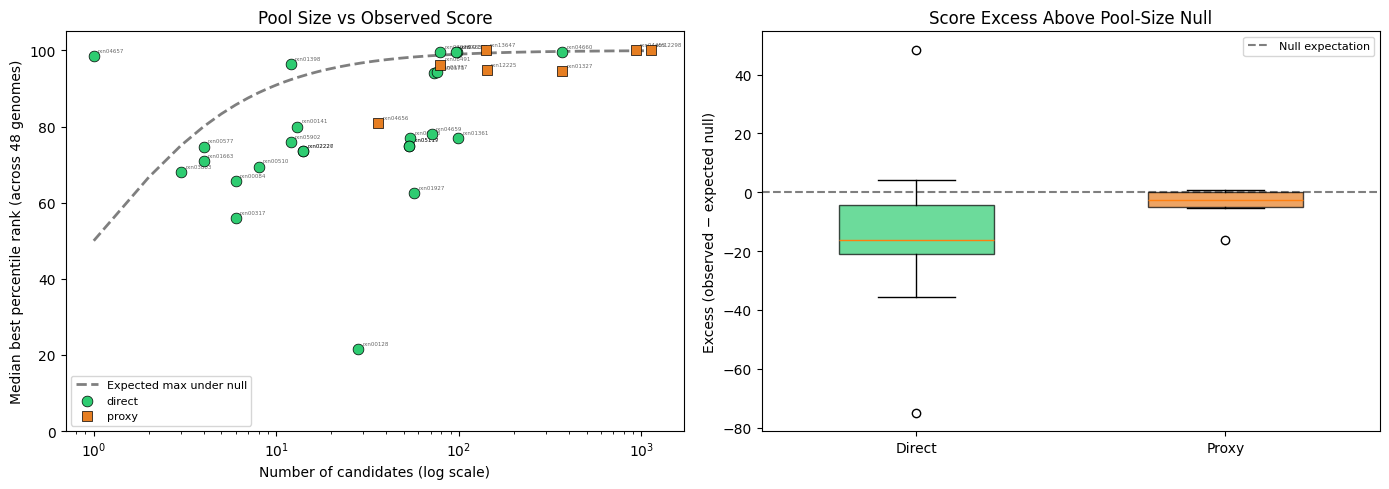

Saved to ../figures/pool_size_forensics.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Pool size vs observed percentile rank with null curve
n_range = np.arange(1, 1200)
null_curve = 100 * n_range / (n_range + 1)
axes[0].plot(n_range, null_curve, 'k--', alpha=0.5, label='Expected max under null', linewidth=2)

for method, color, marker in [('direct', '#2ecc71', 'o'), ('proxy', '#e67e22', 's')]:
    subset = rxn_agg[rxn_agg['method'] == method]
    axes[0].scatter(subset['n_candidates'], subset['median_pct_rank'],
                    c=color, marker=marker, s=60, label=method, edgecolors='black', linewidths=0.5, zorder=5)
    for _, row in subset.iterrows():
        axes[0].annotate(row['rxn'], (row['n_candidates'], row['median_pct_rank']),
                         fontsize=4, alpha=0.6, xytext=(3, 3), textcoords='offset points')

axes[0].set_xscale('log')
axes[0].set_xlabel('Number of candidates (log scale)')
axes[0].set_ylabel('Median best percentile rank (across 48 genomes)')
axes[0].set_title('Pool Size vs Observed Score')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 105)

# Panel 2: Excess by method
direct_excess = rxn_agg[rxn_agg['method'] == 'direct']['excess'].values
proxy_excess = rxn_agg[rxn_agg['method'] == 'proxy']['excess'].values
bp = axes[1].boxplot([direct_excess, proxy_excess], labels=['Direct', 'Proxy'],
                      patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e67e22')
bp['boxes'][1].set_alpha(0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5, label='Null expectation')
axes[1].set_ylabel('Excess (observed − expected null)')
axes[1].set_title('Score Excess Above Pool-Size Null')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'pool_size_forensics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "pool_size_forensics.png"}')

## 2. Pool-Size-Corrected Percentile Rank

The CDF of the max of N independent Uniform(0,1) draws is `F(x) = x^N`.
Apply this to transform raw percentile rank into a pool-size-adjusted score.

In [4]:
bh = best_hits.copy()

p_frac = bh['best_percentile_rank'] / 100.0
p_frac = np.clip(p_frac, 0.001, 200.0 / 201.0)
bh['corrected_pct_rank'] = (p_frac ** bh['n_candidates']) * 100

bh['method'] = bh['rxn'].map(rxn_method)

corrected_agg = bh.groupby('rxn').agg(
    raw_median=('best_percentile_rank', 'median'),
    corrected_median=('corrected_pct_rank', 'median'),
    n_candidates=('n_candidates', 'first'),
    method=('method', 'first')
).reset_index().sort_values('corrected_median', ascending=False)

print('=== Pool-Size Correction Impact ===')
for method in ['direct', 'proxy']:
    subset = corrected_agg[corrected_agg['method'] == method]
    print(f'\n{method.upper()} ({len(subset)} reactions):')
    print(f'  Raw median pct rank:       {subset["raw_median"].median():.1f}')
    print(f'  Corrected median pct rank: {subset["corrected_median"].median():.2f}')

print(f'\nTop 10 reactions by corrected score:')
display(corrected_agg.head(10))
print(f'\nBottom 10 reactions by corrected score:')
display(corrected_agg.tail(10))

=== Pool-Size Correction Impact ===

DIRECT (25 reactions):
  Raw median pct rank:       76.0
  Corrected median pct rank: 3.71

PROXY (7 reactions):
  Raw median pct rank:       96.2
  Corrected median pct rank: 0.36

Top 10 reactions by corrected score:


,rxn,raw_median,corrected_median,n_candidates,method
21,rxn04657,98.50,98.500000,1,direct
18,rxn03978,99.50,67.301288,79,direct
10,rxn01398,96.50,65.212036,12,direct
22,rxn04658,99.50,61.803882,96,direct
14,rxn02107,99.50,61.187388,98,direct
31,rxn13647,100.00,49.745220,140,proxy
17,rxn03883,68.00,31.443200,3,direct
6,rxn00577,74.75,31.222950,4,direct
11,rxn01663,71.00,25.411681,4,direct
24,rxn04660,99.50,15.729568,369,direct



Bottom 10 reactions by corrected score:


,rxn,raw_median,corrected_median,n_candidates,method
20,rxn04656,81.00,5.075288e-02,36,proxy
29,rxn12225,94.75,5.056262e-02,142,proxy
7,rxn00738,77.00,7.421628e-05,54,direct
26,rxn05119,75.00,2.389169e-05,53,direct
25,rxn05117,75.00,2.389169e-05,53,direct
23,rxn04659,78.00,2.181307e-06,71,direct
8,rxn01327,94.50,9.097154e-08,368,proxy
9,rxn01361,77.00,5.788710e-10,99,direct
13,rxn01927,62.50,2.318254e-10,57,direct
1,rxn00128,21.50,2.033653e-17,28,direct


## 3. Permutation Null Model

For each reaction, test whether its candidate pool scores better than
random pools of the same size drawn from the full embedding set.
Uses one representative genome (cross-genome std is negligible).

In [5]:
REP_GENOME = '219790_10_1'
genome_idx = faiss.read_index(str(GENOME_DIR / f'{REP_GENOME}-protein{FASTA_EXT}.faiss'))
print(f'Loaded genome index: {REP_GENOME} ({genome_idx.ntotal} proteins, dim={genome_idx.d})')

rxn_to_proteins = candidates.groupby('rxn')['uniprot_id'].apply(
    lambda x: [uid for uid in x.unique() if uid in emb_map]
).to_dict()
rxn_to_proteins = {r: ps for r, ps in rxn_to_proteins.items() if ps}

all_protein_ids = sorted(emb_map.keys())
pid_to_idx = {pid: i for i, pid in enumerate(all_protein_ids)}

all_vecs = np.vstack([emb_map[pid].reshape(1, -1) for pid in all_protein_ids]).astype('float32')
D_all, _ = genome_idx.search(all_vecs, 1)
all_top1_scores = D_all[:, 0].astype(np.float64)

print(f'Precomputed top-1 cosine for all {len(all_protein_ids)} proteins vs genome')
print(f'  Score range: {all_top1_scores.min():.4f} - {all_top1_scores.max():.4f}')
print(f'  Median: {np.median(all_top1_scores):.4f}')

print(f'\nReactions to test: {len(rxn_to_proteins)}')

Loaded genome index: 219790_10_1 (4518 proteins, dim=1280)


Precomputed top-1 cosine for all 3168 proteins vs genome
  Score range: 0.8107 - 1.0000
  Median: 0.9749

Reactions to test: 32


In [6]:
N_PERM = 1000
rng = np.random.default_rng(42)

perm_results = []

for ri, (rxn, real_proteins) in enumerate(sorted(rxn_to_proteins.items())):
    n = len(real_proteins)
    real_indices = np.array([pid_to_idx[pid] for pid in real_proteins])
    real_best = float(all_top1_scores[real_indices].max())

    exclude_set = set(real_indices)
    available_indices = np.array([i for i in range(len(all_protein_ids)) if i not in exclude_set])

    null_bests = np.zeros(N_PERM)
    for k in range(N_PERM):
        draw = rng.choice(available_indices, size=min(n, len(available_indices)), replace=False)
        null_bests[k] = all_top1_scores[draw].max()

    p_value = float((null_bests >= real_best).sum() + 1) / (N_PERM + 1)

    perm_results.append({
        'rxn': rxn,
        'n_candidates': n,
        'real_best_cosine': real_best,
        'null_mean': float(null_bests.mean()),
        'null_std': float(null_bests.std()),
        'null_max': float(null_bests.max()),
        'perm_pvalue': p_value,
        'method': rxn_method.get(rxn, 'unknown')
    })

    if (ri + 1) % 8 == 0 or ri == 0:
        print(f'  {ri+1}/{len(rxn_to_proteins)}: {rxn} (n={n}) — real={real_best:.4f}, null_mean={null_bests.mean():.4f}, p={p_value:.4f}')

perm_df = pd.DataFrame(perm_results)
print(f'\nPermutation test complete for {len(perm_df)} reactions')
print(f'\nSignificant at p < 0.05: {(perm_df["perm_pvalue"] < 0.05).sum()}')
print(f'Significant at p < 0.01: {(perm_df["perm_pvalue"] < 0.01).sum()}')
print(f'Significant at p < 0.001: {(perm_df["perm_pvalue"] < 0.001).sum()}')

  1/32: rxn00084 (n=6) — real=0.9773, null_mean=0.9951, p=0.9690
  8/32: rxn00738 (n=54) — real=0.9854, null_mean=1.0000, p=1.0000


  16/32: rxn02226 (n=14) — real=0.9817, null_mean=0.9992, p=0.9980
  24/32: rxn04659 (n=71) — real=0.9873, null_mean=1.0000, p=1.0000


  32/32: rxn13647 (n=140) — real=1.0000, null_mean=1.0000, p=0.6314

Permutation test complete for 32 reactions

Significant at p < 0.05: 2
Significant at p < 0.01: 1
Significant at p < 0.001: 1


In [7]:
print('=== Permutation Results by Method ===')
for method in ['direct', 'proxy']:
    subset = perm_df[perm_df['method'] == method]
    print(f'\n{method.upper()} ({len(subset)} reactions):')
    print(f'  Significant (p < 0.05): {(subset["perm_pvalue"] < 0.05).sum()} / {len(subset)}')
    print(f'  Median p-value: {subset["perm_pvalue"].median():.4f}')
    print(f'  Real best cosine (median): {subset["real_best_cosine"].median():.4f}')
    print(f'  Null mean cosine (median): {subset["null_mean"].median():.4f}')

display(perm_df.sort_values('perm_pvalue'))

=== Permutation Results by Method ===

DIRECT (25 reactions):
  Significant (p < 0.05): 2 / 25
  Median p-value: 0.9890
  Real best cosine (median): 0.9841
  Null mean cosine (median): 0.9998

PROXY (7 reactions):
  Significant (p < 0.05): 0 / 7
  Median p-value: 1.0000
  Real best cosine (median): 0.9999
  Null mean cosine (median): 1.0000


,rxn,n_candidates,real_best_cosine,null_mean,null_std,null_max,perm_pvalue,method
24,rxn04660,369,1.000000,0.999999,1.518377e-06,1.0,0.000999,direct
21,rxn04657,1,0.999965,0.970997,2.743502e-02,1.0,0.027972,direct
14,rxn02107,98,0.999998,0.999990,1.969172e-05,1.0,0.411588,direct
22,rxn04658,96,0.999998,0.999990,1.930589e-05,1.0,0.413586,direct
10,rxn01398,12,0.999923,0.998652,3.102309e-03,1.0,0.423576,direct
19,rxn04455,929,1.000000,0.999999,1.237144e-06,1.0,0.445554,proxy
18,rxn03978,79,0.999992,0.999984,3.744255e-05,1.0,0.502498,direct
31,rxn13647,140,0.999998,0.999995,9.995165e-06,1.0,0.631369,proxy
6,rxn00577,4,0.983261,0.991927,9.453413e-03,1.0,0.783217,direct
17,rxn03883,3,0.977975,0.989093,1.135332e-02,1.0,0.796204,direct


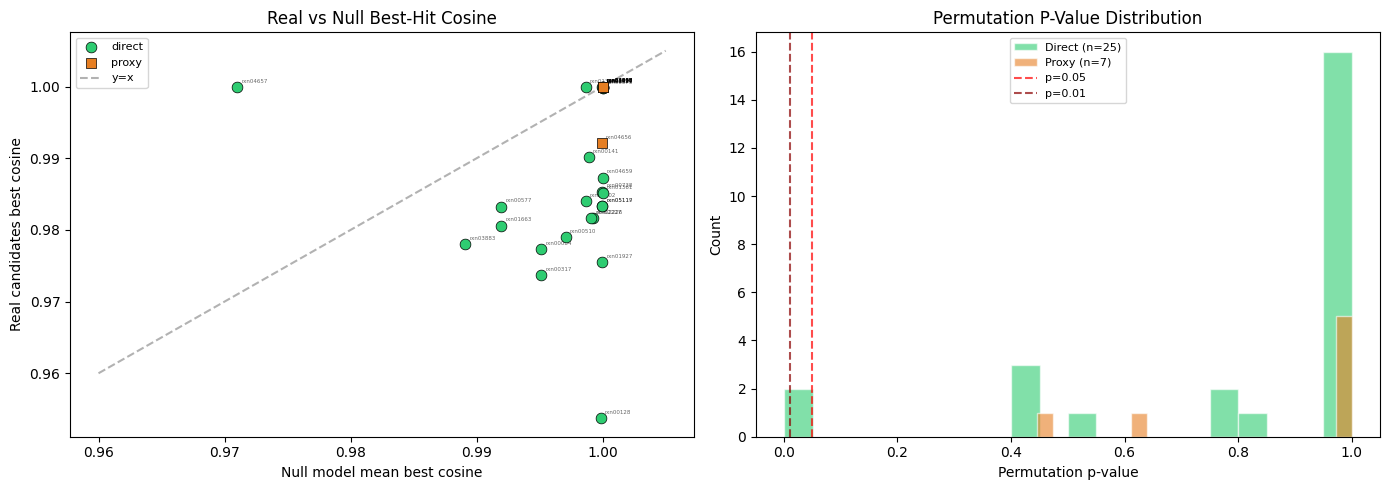

Saved to ../figures/permutation_null.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Real vs null best cosine, colored by method
for method, color, marker in [('direct', '#2ecc71', 'o'), ('proxy', '#e67e22', 's')]:
    subset = perm_df[perm_df['method'] == method]
    axes[0].scatter(subset['null_mean'], subset['real_best_cosine'],
                    c=color, marker=marker, s=60, label=method,
                    edgecolors='black', linewidths=0.5, zorder=5)
    for _, row in subset.iterrows():
        axes[0].annotate(row['rxn'], (row['null_mean'], row['real_best_cosine']),
                         fontsize=4, alpha=0.6, xytext=(3, 3), textcoords='offset points')

lims = [0.96, 1.005]
axes[0].plot(lims, lims, 'k--', alpha=0.3, label='y=x')
axes[0].set_xlabel('Null model mean best cosine')
axes[0].set_ylabel('Real candidates best cosine')
axes[0].set_title('Real vs Null Best-Hit Cosine')
axes[0].legend(fontsize=8)

# Panel 2: P-value distribution by method
direct_p = perm_df[perm_df['method'] == 'direct']['perm_pvalue'].values
proxy_p = perm_df[perm_df['method'] == 'proxy']['perm_pvalue'].values

axes[1].hist(direct_p, bins=20, alpha=0.6, color='#2ecc71', label=f'Direct (n={len(direct_p)})', edgecolor='white')
axes[1].hist(proxy_p, bins=20, alpha=0.6, color='#e67e22', label=f'Proxy (n={len(proxy_p)})', edgecolor='white')
axes[1].axvline(0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
axes[1].axvline(0.01, color='darkred', linestyle='--', alpha=0.7, label='p=0.01')
axes[1].set_xlabel('Permutation p-value')
axes[1].set_ylabel('Count')
axes[1].set_title('Permutation P-Value Distribution')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'permutation_null.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "permutation_null.png"}')

## 4. Cross-Reaction Specificity

Is the best candidate truly reaction-specific, or would candidates
from any reaction score similarly against this genome?

In [9]:
rxn_real_scores = {}
for rxn, proteins in rxn_to_proteins.items():
    indices = np.array([pid_to_idx[pid] for pid in proteins])
    rxn_real_scores[rxn] = float(all_top1_scores[indices].max())

rxn_list = sorted(rxn_to_proteins.keys())
cross_scores = {}

for rxn in rxn_list:
    other_scores = []
    for other_rxn in rxn_list:
        if other_rxn == rxn:
            continue
        other_scores.append(rxn_real_scores[other_rxn])
    other_scores = np.array(other_scores)
    real = rxn_real_scores[rxn]
    z = (real - other_scores.mean()) / other_scores.std() if other_scores.std() > 0 else 0.0
    cross_scores[rxn] = {
        'real_best': real,
        'others_mean': float(other_scores.mean()),
        'others_std': float(other_scores.std()),
        'specificity_z': float(z)
    }

spec_df = pd.DataFrame(cross_scores).T
spec_df.index.name = 'rxn'
spec_df = spec_df.reset_index()
spec_df['method'] = spec_df['rxn'].map(rxn_method)

print('=== Cross-Reaction Specificity ===')
for method in ['direct', 'proxy']:
    subset = spec_df[spec_df['method'] == method]
    print(f'\n{method.upper()} ({len(subset)} reactions):')
    print(f'  Specificity z-score median: {subset["specificity_z"].median():.2f}')
    print(f'  Specificity z > 2: {(subset["specificity_z"] > 2).sum()}')
    print(f'  Specificity z > 1: {(subset["specificity_z"] > 1).sum()}')

display(spec_df.sort_values('specificity_z', ascending=False))

=== Cross-Reaction Specificity ===

DIRECT (25 reactions):
  Specificity z-score median: -0.47
  Specificity z > 2: 0
  Specificity z > 1: 0

PROXY (7 reactions):
  Specificity z-score median: 0.98
  Specificity z > 2: 0
  Specificity z > 1: 0


,rxn,real_best,others_mean,others_std,specificity_z,method
24,rxn04660,1.000000,0.988856,0.011237,0.991722,direct
19,rxn04455,1.000000,0.988856,0.011237,0.991716,proxy
14,rxn02107,0.999998,0.988856,0.011237,0.991575,direct
22,rxn04658,0.999998,0.988856,0.011237,0.991575,direct
31,rxn13647,0.999998,0.988856,0.011237,0.991569,proxy
30,rxn12298,0.999998,0.988856,0.011237,0.991569,proxy
18,rxn03978,0.999992,0.988856,0.011237,0.990920,direct
21,rxn04657,0.999965,0.988857,0.011238,0.988370,direct
10,rxn01398,0.999923,0.988858,0.011240,0.984393,direct
8,rxn01327,0.999886,0.988860,0.011241,0.980942,proxy


In [10]:
protein_rxn_count = candidates.groupby('uniprot_id')['rxn'].nunique()
shared_proteins = set(protein_rxn_count[protein_rxn_count > 1].index)
print(f'Proteins appearing in >1 reaction: {len(shared_proteins)} / {candidates["uniprot_id"].nunique()}')

shared_by_rxn = candidates[candidates['uniprot_id'].isin(shared_proteins)].groupby('rxn').agg(
    n_shared=('uniprot_id', 'nunique')
).reset_index()
shared_by_rxn['n_total'] = shared_by_rxn['rxn'].map(rxn_n_cands)
shared_by_rxn['pct_shared'] = (shared_by_rxn['n_shared'] / shared_by_rxn['n_total'] * 100).round(1)
shared_by_rxn['method'] = shared_by_rxn['rxn'].map(rxn_method)

print(f'\n=== Shared Protein Fraction by Method ===')
for method in ['direct', 'proxy']:
    subset = shared_by_rxn[shared_by_rxn['method'] == method]
    if len(subset) > 0:
        print(f'{method.upper()}: median {subset["pct_shared"].median():.1f}% shared')

display(shared_by_rxn.sort_values('pct_shared', ascending=False))

Proteins appearing in >1 reaction: 953 / 3168

=== Shared Protein Fraction by Method ===
DIRECT: median 100.0% shared
PROXY: median 64.3% shared


,rxn,n_shared,n_total,pct_shared,method
3,rxn02227,14,14,100.0,direct
2,rxn02226,14,14,100.0,direct
7,rxn05119,53,53,100.0,direct
6,rxn05117,53,53,100.0,direct
5,rxn04658,96,96,100.0,direct
1,rxn02107,96,98,98.0,direct
8,rxn12225,136,142,95.8,proxy
4,rxn04455,655,929,70.5,proxy
9,rxn12298,655,1126,58.2,proxy
0,rxn01327,136,368,37.0,proxy


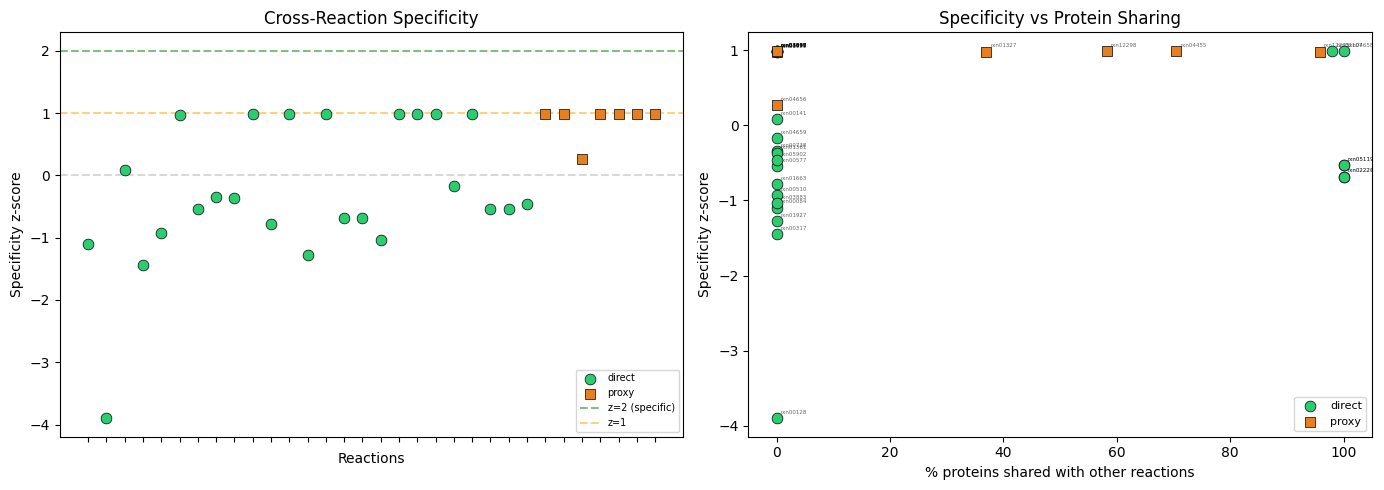

Saved to ../figures/cross_reaction_specificity.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Specificity z-score by method
for method, color, marker in [('direct', '#2ecc71', 'o'), ('proxy', '#e67e22', 's')]:
    subset = spec_df[spec_df['method'] == method]
    axes[0].scatter(subset['rxn'], subset['specificity_z'],
                    c=color, marker=marker, s=60, label=method,
                    edgecolors='black', linewidths=0.5, zorder=5)

axes[0].axhline(2, color='green', linestyle='--', alpha=0.5, label='z=2 (specific)')
axes[0].axhline(1, color='orange', linestyle='--', alpha=0.5, label='z=1')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xticklabels([])
axes[0].set_xlabel('Reactions')
axes[0].set_ylabel('Specificity z-score')
axes[0].set_title('Cross-Reaction Specificity')
axes[0].legend(fontsize=7)

# Panel 2: Shared protein fraction
merged_shared = spec_df.merge(shared_by_rxn[['rxn', 'pct_shared']], on='rxn', how='left')
merged_shared['pct_shared'] = merged_shared['pct_shared'].fillna(0)
for method, color, marker in [('direct', '#2ecc71', 'o'), ('proxy', '#e67e22', 's')]:
    subset = merged_shared[merged_shared['method'] == method]
    axes[1].scatter(subset['pct_shared'], subset['specificity_z'],
                    c=color, marker=marker, s=60, label=method,
                    edgecolors='black', linewidths=0.5, zorder=5)
    for _, row in subset.iterrows():
        axes[1].annotate(row['rxn'], (row['pct_shared'], row['specificity_z']),
                         fontsize=4, alpha=0.6, xytext=(3, 3), textcoords='offset points')

axes[1].set_xlabel('% proteins shared with other reactions')
axes[1].set_ylabel('Specificity z-score')
axes[1].set_title('Specificity vs Protein Sharing')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'cross_reaction_specificity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "cross_reaction_specificity.png"}')

## 5. Corrected Verdicts

Apply method-stratified thresholds using corrected percentile rank,
permutation p-value, and specificity z-score.

In [12]:
verdict_data = corrected_agg[['rxn', 'raw_median', 'corrected_median', 'n_candidates', 'method']].copy()
verdict_data = verdict_data.merge(perm_df[['rxn', 'perm_pvalue', 'real_best_cosine']], on='rxn', how='left')
verdict_data = verdict_data.merge(spec_df[['rxn', 'specificity_z']], on='rxn', how='left')
verdict_data = verdict_data.merge(
    landscape[['rxn', 'confidence']].rename(columns={'confidence': 'evidence_tier'}),
    on='rxn', how='left'
)

def corrected_verdict(row):
    if row['method'] == 'direct':
        if row['corrected_median'] >= 80 and row['perm_pvalue'] < 0.01:
            return 'strong'
        elif row['corrected_median'] >= 50 and row['perm_pvalue'] < 0.05:
            return 'moderate'
        elif row['corrected_median'] >= 20 or row['perm_pvalue'] < 0.10:
            return 'weak'
        else:
            return 'insufficient'
    else:
        if row['perm_pvalue'] < 0.001 and row['specificity_z'] > 2:
            return 'strong'
        elif row['perm_pvalue'] < 0.01 and row['specificity_z'] > 1:
            return 'moderate'
        elif row['perm_pvalue'] < 0.05:
            return 'weak'
        else:
            return 'insufficient'

verdict_data['verdict_corrected'] = verdict_data.apply(corrected_verdict, axis=1)

nb05_map = nb05_verdicts.set_index('rxn')['verdict'].to_dict()
verdict_data['verdict_nb05'] = verdict_data['rxn'].map(nb05_map)

uncovered = all_rxns - scored_rxns
uncovered_rows = []
for rxn in sorted(uncovered):
    tier = landscape[landscape['rxn'] == rxn]['confidence'].values
    tier = tier[0] if len(tier) > 0 else 'unknown'
    uncovered_rows.append({
        'rxn': rxn, 'raw_median': np.nan, 'corrected_median': np.nan,
        'n_candidates': 0, 'method': 'none', 'perm_pvalue': np.nan,
        'real_best_cosine': np.nan, 'specificity_z': np.nan,
        'evidence_tier': tier, 'verdict_corrected': 'no_candidates',
        'verdict_nb05': 'no_candidates'
    })
verdict_data = pd.concat([verdict_data, pd.DataFrame(uncovered_rows)], ignore_index=True)

verdict_data['verdict_change'] = verdict_data.apply(
    lambda r: 'unchanged' if r['verdict_nb05'] == r['verdict_corrected']
    else f"{r['verdict_nb05']} -> {r['verdict_corrected']}", axis=1
)

print('=== Verdict Distribution Comparison ===')
print(f'\nNB05 verdicts:')
print(verdict_data['verdict_nb05'].value_counts().to_string())
print(f'\nCorrected verdicts:')
print(verdict_data['verdict_corrected'].value_counts().to_string())

print(f'\n=== Verdict Changes ===')
changes = verdict_data[verdict_data['verdict_change'] != 'unchanged']
print(f'Changed: {len(changes)} / {len(verdict_data)} reactions')
if len(changes) > 0:
    print(changes[['rxn', 'method', 'n_candidates', 'verdict_nb05', 'verdict_corrected', 'perm_pvalue', 'specificity_z']].to_string(index=False))

=== Verdict Distribution Comparison ===

NB05 verdicts:
verdict_nb05
weak             15
strong           10
no_candidates    10
moderate          6
insufficient      1

Corrected verdicts:
verdict_corrected
insufficient     23
no_candidates    10
weak              8
moderate          1

=== Verdict Changes ===
Changed: 28 / 42 reactions
     rxn method  n_candidates verdict_nb05 verdict_corrected  perm_pvalue  specificity_z
rxn04657 direct             1       strong          moderate     0.027972       0.988370
rxn03978 direct            79       strong              weak     0.502498       0.990920
rxn01398 direct            12       strong              weak     0.423576       0.984393
rxn04658 direct            96       strong              weak     0.413586       0.991575
rxn02107 direct            98       strong              weak     0.411588       0.991575
rxn13647  proxy           140       strong      insufficient     0.631369       0.991569
rxn04660 direct           369       s

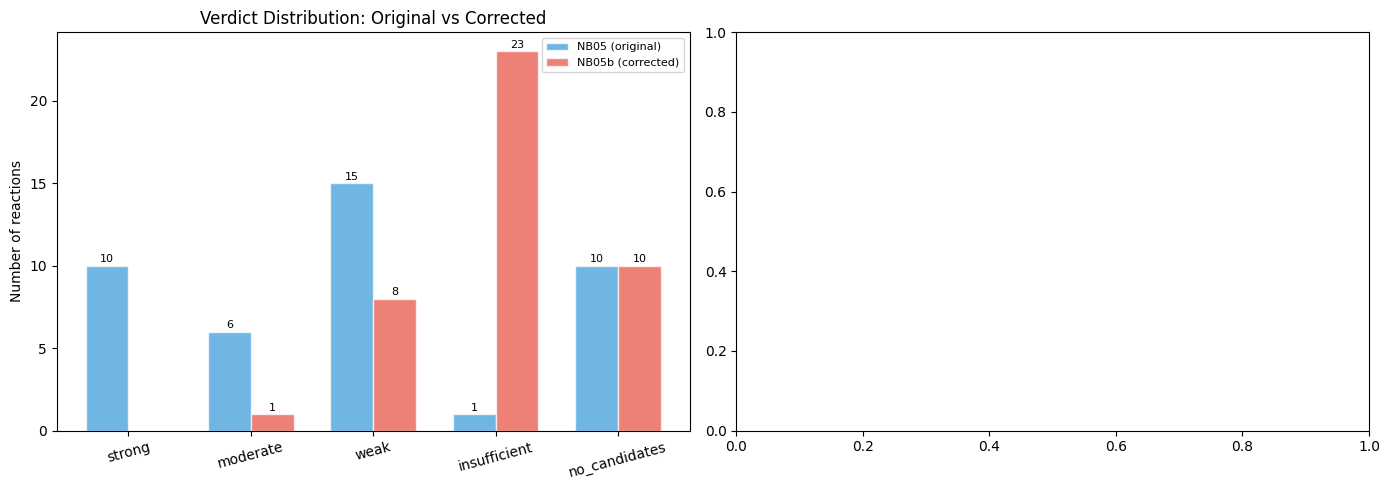

Saved to ../figures/verdict_comparison.png


In [13]:
verdict_order = ['strong', 'moderate', 'weak', 'insufficient', 'no_candidates']
verdict_colors = {'strong': '#27ae60', 'moderate': '#f39c12', 'weak': '#e67e22',
                  'insufficient': '#e74c3c', 'no_candidates': '#95a5a6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Side-by-side verdict bars
nb05_counts = verdict_data['verdict_nb05'].value_counts().reindex(verdict_order).fillna(0)
corr_counts = verdict_data['verdict_corrected'].value_counts().reindex(verdict_order).fillna(0)
x = range(len(verdict_order))
width = 0.35
axes[0].bar([i - width/2 for i in x], nb05_counts.values, width,
            label='NB05 (original)', color='#3498db', alpha=0.7, edgecolor='white')
axes[0].bar([i + width/2 for i in x], corr_counts.values, width,
            label='NB05b (corrected)', color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(verdict_order, rotation=15)
axes[0].set_ylabel('Number of reactions')
axes[0].set_title('Verdict Distribution: Original vs Corrected')
axes[0].legend(fontsize=8)

for i, (v1, v2) in enumerate(zip(nb05_counts.values, corr_counts.values)):
    if v1 > 0:
        axes[0].text(i - width/2, v1 + 0.2, str(int(v1)), ha='center', fontsize=8)
    if v2 > 0:
        axes[0].text(i + width/2, v2 + 0.2, str(int(v2)), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'verdict_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "verdict_comparison.png"}')

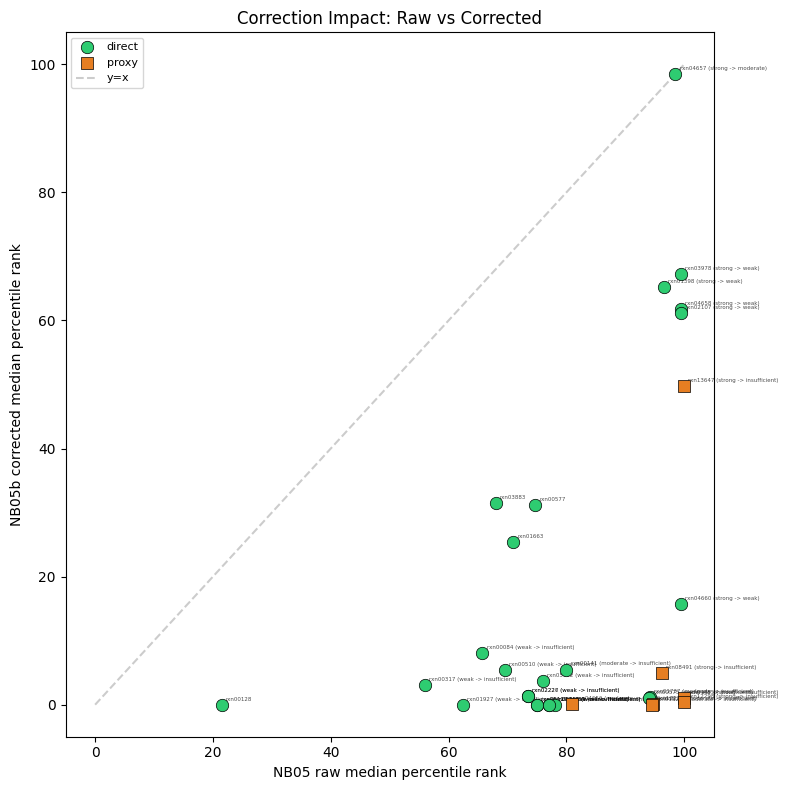

Saved to ../figures/correction_impact.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

scored_v = verdict_data[verdict_data['verdict_corrected'] != 'no_candidates'].copy()

for method, color, marker in [('direct', '#2ecc71', 'o'), ('proxy', '#e67e22', 's')]:
    subset = scored_v[scored_v['method'] == method]
    ax.scatter(subset['raw_median'], subset['corrected_median'],
              c=color, marker=marker, s=80, label=method,
              edgecolors='black', linewidths=0.5, zorder=5)
    for _, row in subset.iterrows():
        label = row['rxn']
        if row['verdict_change'] != 'unchanged':
            label += f' ({row["verdict_change"]})'
        ax.annotate(label, (row['raw_median'], row['corrected_median']),
                    fontsize=4, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax.plot([0, 100], [0, 100], 'k--', alpha=0.2, label='y=x')
ax.set_xlabel('NB05 raw median percentile rank')
ax.set_ylabel('NB05b corrected median percentile rank')
ax.set_title('Correction Impact: Raw vs Corrected')
ax.legend(fontsize=8)
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig(FIG / 'correction_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "correction_impact.png"}')

## 6. Revised Hypothesis Evaluation

In [15]:
scored_v = verdict_data[verdict_data['verdict_corrected'] != 'no_candidates']
strong = (scored_v['verdict_corrected'] == 'strong').sum()
moderate = (scored_v['verdict_corrected'] == 'moderate').sum()
weak = (scored_v['verdict_corrected'] == 'weak').sum()
insuf = (scored_v['verdict_corrected'] == 'insufficient').sum()
actionable = strong + moderate

direct_scored = scored_v[scored_v['method'] == 'direct']
proxy_scored = scored_v[scored_v['method'] == 'proxy']

print('=' * 70)
print('REVISED HYPOTHESIS EVALUATION (NB05b)')
print('=' * 70)

print(f'\n--- Corrected Verdicts ---')
print(f'Strong:       {strong}')
print(f'Moderate:     {moderate}')
print(f'Weak:         {weak}')
print(f'Insufficient: {insuf}')
print(f'No candidates: {len(verdict_data) - len(scored_v)}')
print(f'Actionable (strong + moderate): {actionable} / {len(scored_v)} scored ({100*actionable/len(scored_v):.0f}%)')

print(f'\n--- Method-Stratified Results ---')
print(f'Direct reactions: {(direct_scored["verdict_corrected"].isin(["strong", "moderate"])).sum()} / {len(direct_scored)} actionable')
print(f'Proxy reactions:  {(proxy_scored["verdict_corrected"].isin(["strong", "moderate"])).sum()} / {len(proxy_scored)} actionable')

print(f'\n--- Evidence Tier Correlation (corrected) ---')
high_tier = scored_v[scored_v['evidence_tier'] == 'high']
none_tier = scored_v[scored_v['evidence_tier'].isin(['none', 'missing'])]
if len(high_tier) > 0 and len(none_tier) > 0:
    print(f'High-evidence reactions: median corrected pct = {high_tier["corrected_median"].median():.2f}')
    print(f'No-evidence reactions:   median corrected pct = {none_tier["corrected_median"].median():.2f}')
    direction = 'CORRECT' if high_tier['corrected_median'].median() > none_tier['corrected_median'].median() else 'STILL INVERTED'
    print(f'Direction: {direction}')

print(f'\n--- Verdict ---')
if actionable / len(scored_v) >= 0.3:
    print(f'H1 SUPPORTED (corrected): After pool-size correction and permutation testing,')
    print(f'{actionable}/{len(scored_v)} reactions retain moderate-to-strong evidence.')
    print(f'The embedding approach provides genuine gap-filling evidence when properly')
    print(f'controlled for pool size and selection bias.')
else:
    print(f'H1 WEAKLY SUPPORTED: After correction, only {actionable}/{len(scored_v)} reactions')
    print(f'retain actionable evidence. The embedding approach provides some signal but')
    print(f'much of the apparent evidence in NB05 was inflated by pool size and selection bias.')

print(f'\n--- Key Methodological Finding ---')
print(f'The NB05 proxy inflation was primarily a max-of-N order statistic artifact.')
print(f'Pool-size correction and permutation testing are essential for any')
print(f'embedding-based gap-filling pipeline that compares candidate pools of')
print(f'different sizes.')

REVISED HYPOTHESIS EVALUATION (NB05b)

--- Corrected Verdicts ---
Strong:       0
Moderate:     1
Weak:         8
Insufficient: 23
No candidates: 10
Actionable (strong + moderate): 1 / 32 scored (3%)

--- Method-Stratified Results ---
Direct reactions: 1 / 25 actionable
Proxy reactions:  0 / 7 actionable

--- Evidence Tier Correlation (corrected) ---
High-evidence reactions: median corrected pct = 3.40
No-evidence reactions:   median corrected pct = 0.67
Direction: CORRECT

--- Verdict ---
H1 WEAKLY SUPPORTED: After correction, only 1/32 reactions
retain actionable evidence. The embedding approach provides some signal but
much of the apparent evidence in NB05 was inflated by pool size and selection bias.

--- Key Methodological Finding ---
The NB05 proxy inflation was primarily a max-of-N order statistic artifact.
Pool-size correction and permutation testing are essential for any
embedding-based gap-filling pipeline that compares candidate pools of
different sizes.


## 7. Save Outputs

In [16]:
output_cols = ['rxn', 'evidence_tier', 'method', 'n_candidates',
               'raw_median', 'corrected_median', 'perm_pvalue',
               'real_best_cosine', 'specificity_z',
               'verdict_nb05', 'verdict_corrected', 'verdict_change']
verdict_data[output_cols].sort_values('rxn').to_csv(
    DATA / 'reaction_verdicts_corrected.csv', index=False
)

print(f'Saved {len(verdict_data)} reaction verdicts to data/reaction_verdicts_corrected.csv')
print(f'\nFigures saved:')
for fig_name in ['pool_size_forensics', 'permutation_null',
                  'cross_reaction_specificity', 'verdict_comparison', 'correction_impact']:
    path = FIG / f'{fig_name}.png'
    print(f'  {path} ({path.stat().st_size // 1024}K)' if path.exists() else f'  {path} MISSING')

Saved 42 reaction verdicts to data/reaction_verdicts_corrected.csv

Figures saved:
  ../figures/pool_size_forensics.png (101K)
  ../figures/permutation_null.png (92K)
  ../figures/cross_reaction_specificity.png (78K)
  ../figures/verdict_comparison.png (54K)
  ../figures/correction_impact.png (95K)
